# Ellipsometry LiF 9/16/26

We just received a new set of ellipsometry data from Woollam in file
 Blue Ridge_LiF on Glass WA0904_2026_06_Sept 16.xlsx

This adds a 1 mm spacing data set on the glass sample from the 6/26 run and then 2 mm sets on both LiF on etched Si and LiF on unetched Si. From the pictures in the spreadsheet these are all in good qualitative agreement with the previous 6/26 data and it looks as though the 1 mm glass data will be a good match for the 2 mm data. It is interesting to note that the etched wafer data show a much larger spread in thicknesses than either the glass or the unetched. There is significant variation from wafer to wafer apparently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from DepositData4 import DepositData4

In [2]:
g1mm = DepositData4.from_file('Run9_17_WA0904_1mm.txt', 'Glass 1mm')

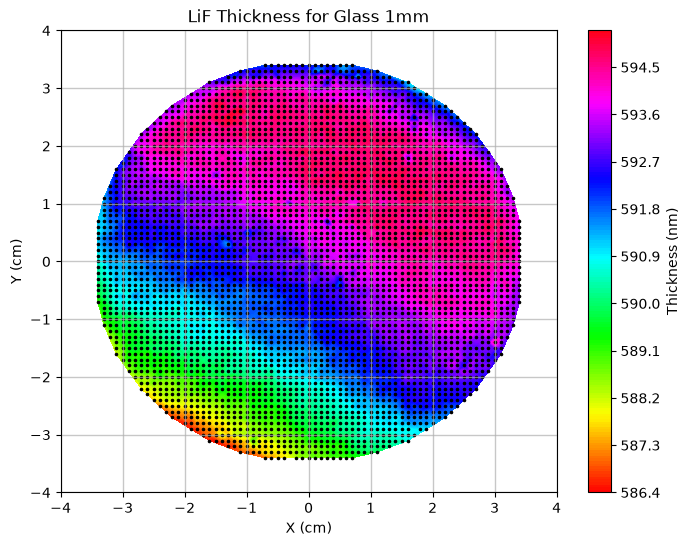

In [3]:
g1mm.Ron_plot()

and for comparison here is map 4 from the earlier series, the same sammple in the same orientation.

In [4]:
S4 = DepositData4.from_file('Run6_26_Scan4.txt', 'Scan4')

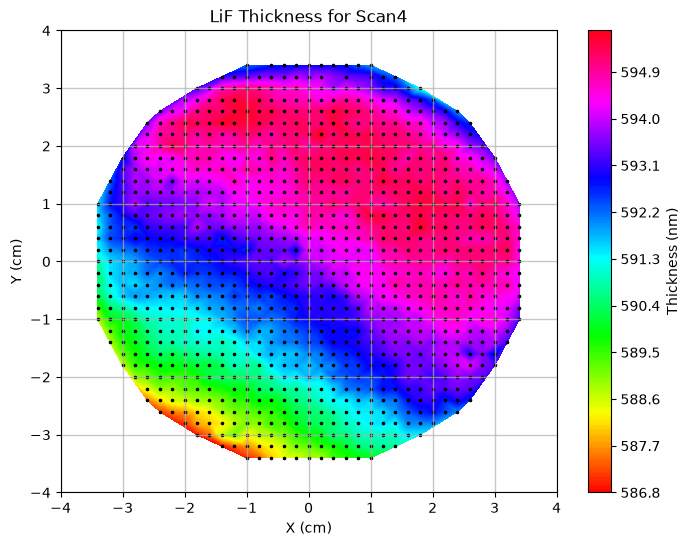

In [5]:
S4.Ron_plot()

These are simple thickness plots and do not take into account the variation in refractive index.

Now can we compare them. Because the points are different it is not trivial. What we can do, however, is to fit both sets and then look at the difference between the fits.

In [6]:
ipg = [ 5.938e+02,  1.045e+00, -9.325e-01,  1.174e-01,  1.869e-02]

def quart_fit(p, a):
    return DepositData4.fit_helper(p, a, 'angled_quartic')

In [7]:
g1f =g1mm.fit_to(quart_fit, ipg)
print(g1f)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 553.174408432074
        x: [ 5.933e+02  1.057e+00 -9.097e-01  1.090e-01  1.896e-02]
      nit: 13
      jac: [-1.526e-05  3.510e-04 -1.068e-04  3.052e-05 -3.967e-04]
 hess_inv: [[ 4.391e-04 -7.234e-05 ...  1.788e-04 -1.409e-05]
            [-7.234e-05  2.046e-05 ... -5.150e-05  4.920e-06]
            ...
            [ 1.788e-04 -5.150e-05 ...  1.300e-04 -1.247e-05]
            [-1.409e-05  4.920e-06 ... -1.247e-05  1.354e-06]]
     nfev: 354
     njev: 57


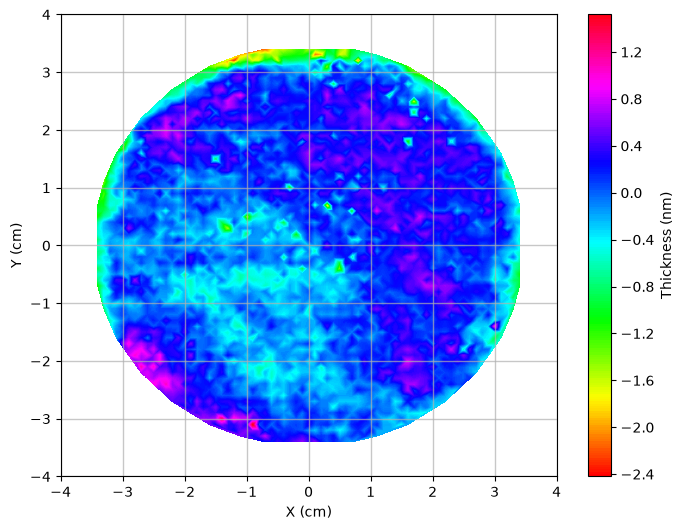

In [8]:
g1mm.contour_plot(g1mm.resids)

Now compare to Scan4.

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 174.71335304511177
        x: [ 5.938e+02  1.045e+00 -9.325e-01  1.174e-01  1.869e-02]
      nit: 9
      jac: [ 0.000e+00  8.011e-05  1.335e-04 -1.583e-04 -4.406e-04]
 hess_inv: [[ 1.527e-03 -1.281e-05 ...  6.453e-04 -5.115e-05]
            [-1.281e-05  1.026e-04 ... -1.725e-05  2.132e-06]
            ...
            [ 6.453e-04 -1.725e-05 ...  5.130e-04 -4.889e-05]
            [-5.115e-05  2.132e-06 ... -4.889e-05  5.184e-06]]
     nfev: 252
     njev: 40


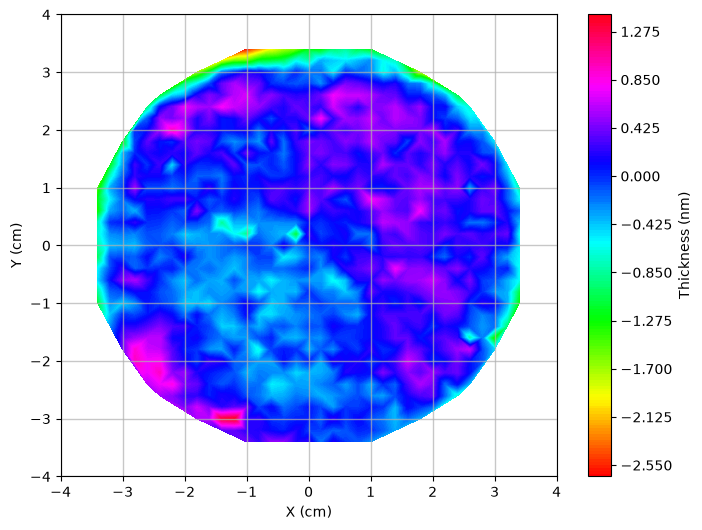

In [9]:
rq4 =S4.fit_to(quart_fit, [5.935e+02,  1.059e+00, -8.697e-01, 0.1,  2.958e-02])
print(rq4)
S4.contour_plot(S4.resids)

So rather similar, though the worst residuals are larger for the 1mm data than for the 2mm.

Let's look at the parameters.

In [10]:
print(g1f.x)
print(rq4.x)
print(100 * (g1f.x - rq4.x) / rq4.x)

[ 5.93274472e+02  1.05656903e+00 -9.09712556e-01  1.09044719e-01
  1.89563978e-02]
[ 5.93831303e+02  1.04506906e+00 -9.32511264e-01  1.17435131e-01
  1.86903254e-02]
[-0.09376923  1.10040277 -2.44487218 -7.14472065  1.42358396]


So we know the parameters at the few % level.

Let's see if we can look a the difference between the fits.

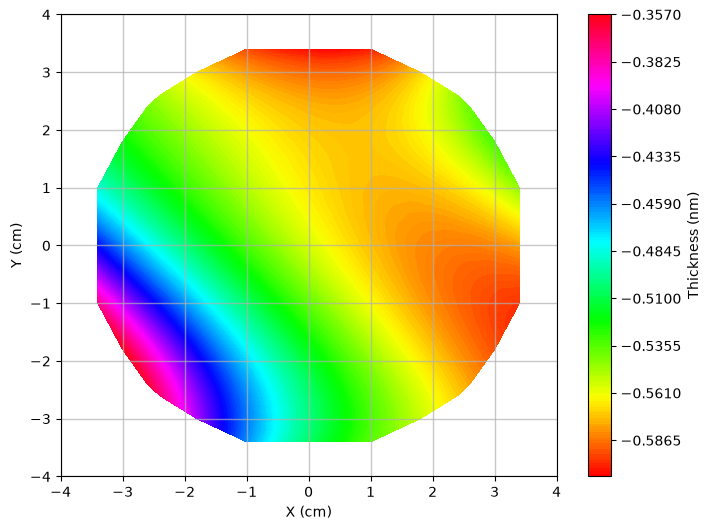

In [11]:
gfit = S4.angled_quartic(g1f.x)
S4fit = S4.angled_quartic(rq4.x)
diff = gfit-S4fit
S4.contour_plot(diff)

Interesting. Now I really need a way to pull a 2 mm map out of the 1 mm map to compute noise directly.

## Subsetting

So long as two data sets share the same dx=dy and the same origin, which all so far do, it should be possible to extract the 2 mm subset from the 1 mm map. Indeed
it should not even need fancy searching. If the ratio of the sizes is an integer then we should be able to simply index through the arrays at different rates, emitting all points that were valid in the larger source array. This does not need to be a class method but will need to operate on the (public) instance variables.

I have implemented this in subset.py.

1.9999999999999956 2
-4.440892098500626e-15 4.440892098500626e-15
(4761,)
(1225,)
0.0
0.0
Pattern starts at ((np.float64(-3.4), np.float64(-3.4))
Source starts at ((np.float64(-3.4), np.float64(-3.4))
Subset complete. Skipped 246 points


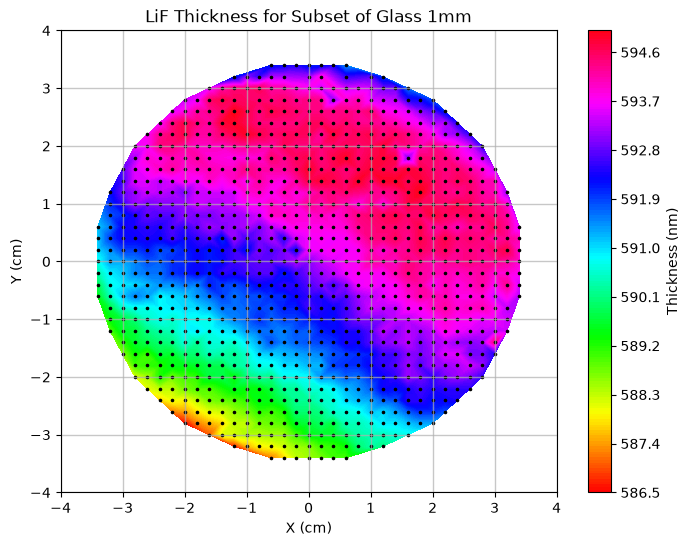

In [12]:
from subset import subset

g2mm = subset(g1mm, S4)
g2mm.Ron_plot()

Now we can look at the difference between Scan4 and the subset of the 1 mm map.

In [13]:
i_mask = np.logical_and(S4.mask, g2mm.mask)

Text(0, 0.5, 'Y (cm)')

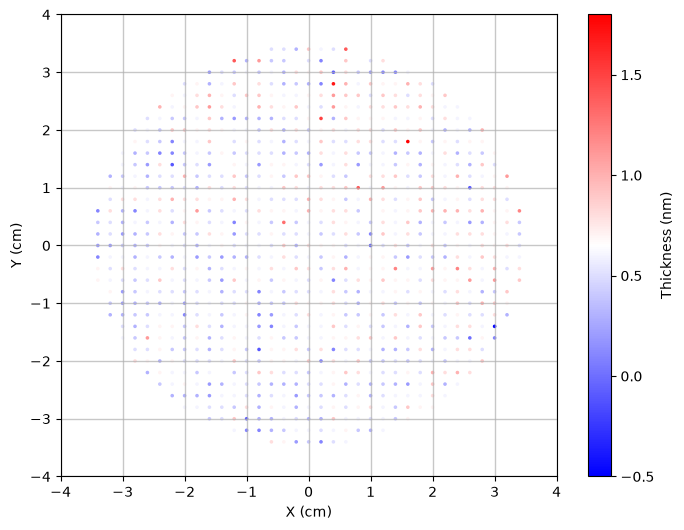

In [14]:
zdiff = S4.zdata - g2mm.zdata
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(S4.xdata[i_mask], S4.ydata[i_mask], c=zdiff[i_mask], marker='.', cmap='bwr', s=10)
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')


That is very consistent with the previous difference maps. Here is the histogram.

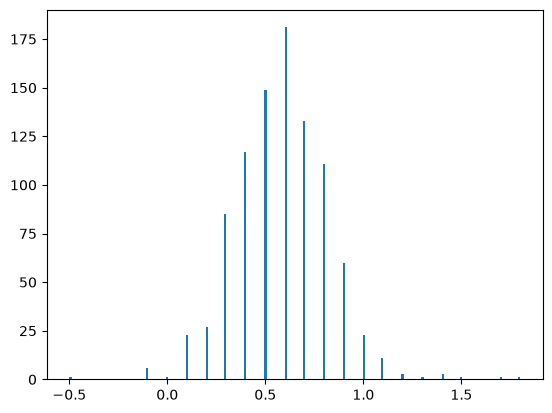

In [15]:
h1 = plt.hist(zdiff[i_mask], bins=201)

Absolutely in line with the previous results.

We can do a similar thing with the data from the fits.

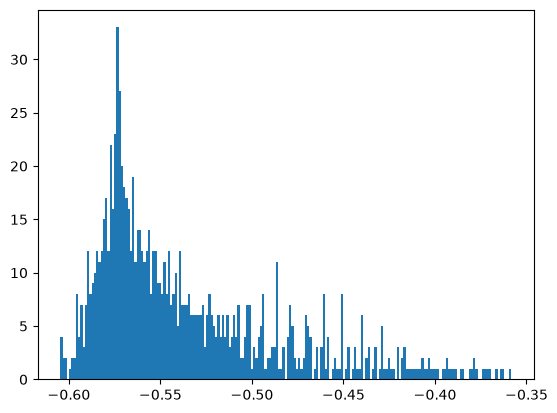

In [16]:
h2 = plt.hist(diff[S4.mask], bins=201)

That is considerably tighter in the main peak, though with a longer tail. The same slight difference in average value shows up with the opposite sign because we did the difference the other way.